Vector3<16.0, 8.0, 0.0>
-----------
Initializing structure...
time for choose_chunkdivision = 0.000557899 s
Working in 2D dimensions.
Computational cell is 16 x 8 x 0 with resolution 20
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
time for set_epsilon = 0.179262 s
-----------
run 0 finished at t = 200.0 (8000 timesteps)


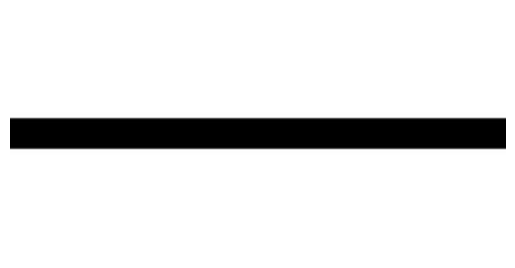

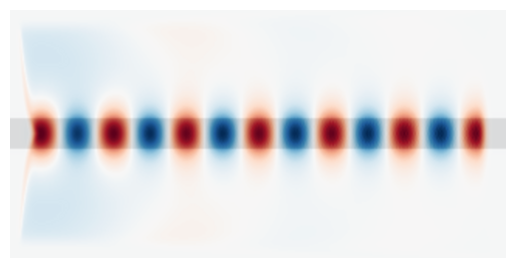

In [17]:
import meep as mp
import matplotlib.pyplot as plt
#import numpy as np

cell = mp.Vector3(16,8,0)
print(cell)
geomentry = [mp.Block(mp.Vector3(mp.inf,1,mp.inf),
                      center=mp.Vector3(),
                      material=mp.Medium(epsilon=12))]

sources = [mp.Source(mp.ContinuousSource(frequency=0.15),
                     component=mp.Ez,
                     center=mp.Vector3(-7,0))]

pml_layer = [mp.PML(1.0)]

sim = mp.Simulation(cell_size=cell, boundary_layers=pml_layer, geometry=geomentry, sources=sources, resolution=20)
sim.run(until=200)

eps_data = sim.get_array(center=mp.Vector3(), size=cell, component=mp.Dielectric)
plt.figure()
plt.imshow(eps_data.transpose(), interpolation='spline36' ,cmap='binary')
plt.axis('off')
plt.show()

ez_data = sim.get_array(center=mp.Vector3(), size=cell, component=mp.Ez)
plt.figure()
plt.imshow(eps_data.transpose(), interpolation='spline36', cmap='binary')
plt.imshow(ez_data.transpose(), interpolation='spline36', cmap='RdBu', alpha=0.9)
plt.axis('off')
plt.show()

-----------
Initializing structure...
time for choose_chunkdivision = 0.000105143 s
Working in 2D dimensions.
Computational cell is 20 x 10 x 0 with resolution 20
     block, center = (0,0,0)
          size (5,10,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2,2,2)
time for set_epsilon = 0.196679 s
-----------
run 0 finished at t = 100.0 (4000 timesteps)
     block, center = (0,0,0)
          size (5,10,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2,2,2)


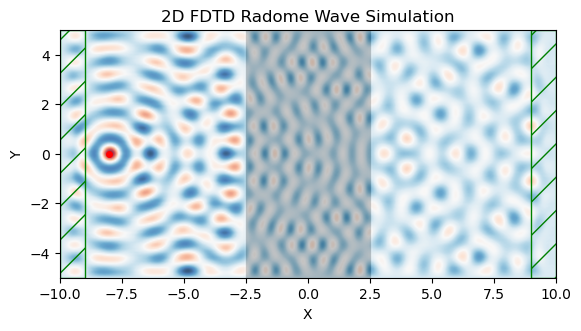

In [111]:
import meep as mp
import matplotlib.pyplot as plt

sx = 20
sy = 10
cell = mp.Vector3(sx,sy,0)

freq = 1
src_pos = -sx/2 + 2.0
radome_t = 1.5
radome_center = 2.0 
epsilon_r = 2 #refer the TI paper for epsilon_r reason on why 3 ?

geometry = [mp.Block(size = mp.Vector3(5, 10, mp.inf),
                              material = mp.Medium(epsilon = epsilon_r))]

sources = [mp.Source(mp.ContinuousSource(frequency=freq),
                     component = mp.Ez,
                     center = mp.Vector3(src_pos, 0, 0))]

pml_layers = [mp.PML(1,0)]

sim = mp.Simulation(cell_size=cell, boundary_layers=pml_layers, geometry=geometry, sources=sources, resolution=20)

sim.run(until=100)

plt.figure()
sim.plot2D(fields=mp.Ez)
plt.title("2D FDTD Radome Wave Simulation")
plt.show()

     sphere, center = (0,4,0)
          radius 7
          dielectric constant epsilon diagonal = (2.1,2.1,2.1)
     block, center = (0,-10,0)
          size (1e+20,20,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (0,-0.5,0)
          size (12,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.1,2.1,2.1)


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


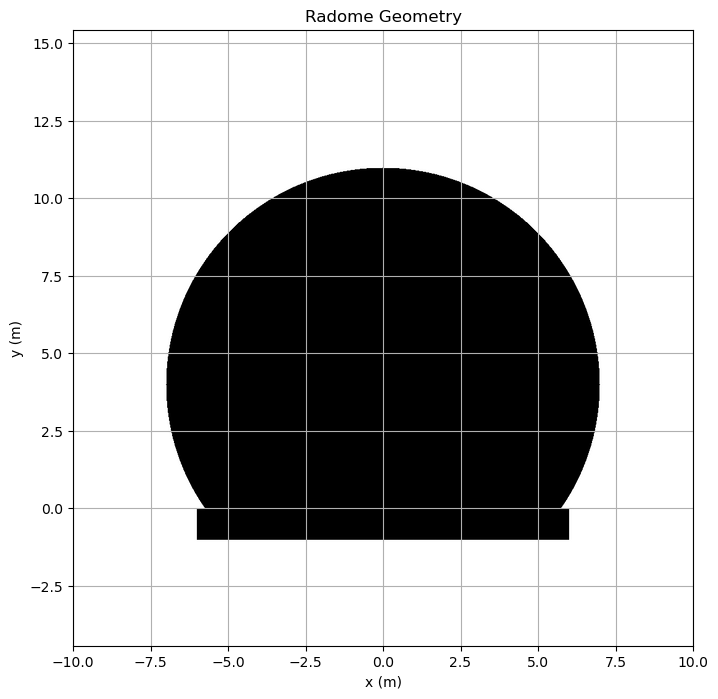

In [26]:
import meep as mp
import matplotlib.pyplot as plt

# --------------------------------------------------
# Parameters
# --------------------------------------------------

eps_radome = 2.1
radome_mat = mp.Medium(epsilon=eps_radome)

cell = mp.Vector3(20,25,0)

# --------------------------------------------------
# Geometry
# --------------------------------------------------

geometry = [

    # Full circle
    mp.Sphere(
        radius=7,
        center=mp.Vector3(0,4),
        material=radome_mat
    ),

    # Air block removes lower half
    mp.Block(
        size=mp.Vector3(mp.inf,20,mp.inf),
        center=mp.Vector3(0,-10),
        material=mp.air
    ),

    # Base slab
    mp.Block(
        size=mp.Vector3(12,1,mp.inf),
        center=mp.Vector3(0,-0.5),
        material=radome_mat
    )
]

# --------------------------------------------------
# Simulation
# --------------------------------------------------

sim = mp.Simulation(
    cell_size=cell,
    geometry=geometry,
    resolution=50
)

# --------------------------------------------------
# Plot geometry
# --------------------------------------------------

plt.figure(figsize=(8,8))

sim.plot2D()

plt.title("Radome Geometry")
plt.xlabel("x (m)")
plt.ylabel("y (m)")

plt.axis("equal")
plt.xlim(-10,10)
plt.ylim(-2,13)

plt.grid(True)

plt.show()

-----------
Initializing structure...
time for choose_chunkdivision = 0.00111794 s
Working in 2D dimensions.
Computational cell is 20 x 24 x 0 with resolution 20
     sphere, center = (0,-12,0)
          radius 7
          dielectric constant epsilon diagonal = (2,2,2)
     sphere, center = (0,-12,0)
          radius 6
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.821055 s
-----------
Meep progress: 44.25/1000.0 = 4.4% done in 4.0s, 86.4s to go
on time step 1770 (time=44.25), 0.00226061 s/step
Meep progress: 94.325/1000.0 = 9.4% done in 8.0s, 76.8s to go
on time step 3773 (time=94.325), 0.00199753 s/step
Meep progress: 137.525/1000.0 = 13.8% done in 12.0s, 75.3s to go
on time step 5502 (time=137.55), 0.00231382 s/step
Meep progress: 188.57500000000002/1000.0 = 18.9% done in 16.0s, 68.9s to go
on time step 7545 (time=188.625), 0.00195842 s/step
Meep progress: 240.32500000000002/1000.0 = 24.0% done in 20.0s, 63.2s to go
on time step 9615 (time=240.375)

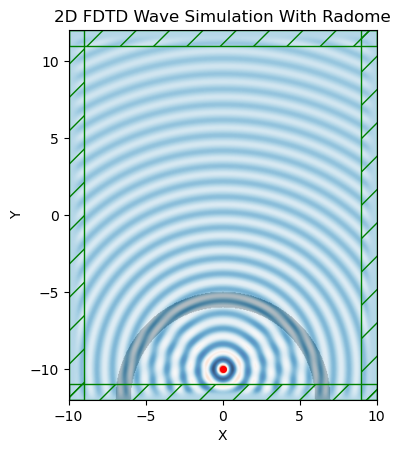

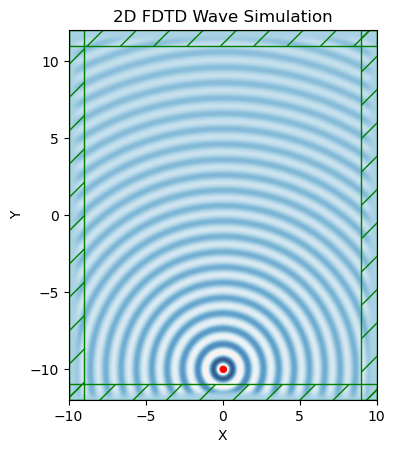

The field data with radome 0.059202461891974416
The field data without radome 0.1111945328828681
Insertion Loss :  5.474873356601818


In [1]:
import meep as mp
import matplotlib.pyplot as plt
import numpy as np

cell = mp.Vector3(20,24,0) # cell is more like a workspace so geomentry defined are into this area has 3 Dimensions but I choose 2D

probe_1 = mp.Vector3(0,4)
probe_2 = mp.Vector3(0,4)

# Parameters Based on TI Radome Design guide paper
freq = 1 # 16GHz based on MEEP unit (Refer notes for more detail) {Ku band}
src_pos = 0
radome_t = 1.5
radome_center = 2.0 
epsilon_r = 2 #refer the TI paper the reason for Er = 2 coz the material is Teflom?
radome_mat = mp.Medium(epsilon = epsilon_r) 

#  Geometry of the Radome based on COMSOL desgin 
radome_dome_rad = 7
geometry = [
    
    mp.Sphere(
        radius = radome_dome_rad,
        center = mp.Vector3(0, -12, 0),
        material = radome_mat
    ),

    mp.Sphere(
        radius = (radome_dome_rad-1),
        center = mp.Vector3(0, -12, 0),
        material = mp.air
    ),


]

sources = [mp.Source(mp.ContinuousSource(frequency=freq),
                     component = mp.Ez,
                     center = mp.Vector3(src_pos, -10, 0))]

pml_layers = [mp.PML(1)]


sim_1 = mp.Simulation(cell_size=cell, boundary_layers=pml_layers, geometry=geometry, sources=sources, resolution=20)
sim_1.run(until=1000)

sim_2 = mp.Simulation(cell_size=cell, boundary_layers=pml_layers, sources=sources, resolution=20)
sim_2.run(until=1000)

Reading_1 = abs(sim_1.get_field_point(mp.Ez, probe_1))
Reading_2 = abs(sim_2.get_field_point(mp.Ez, probe_2))

# Simulation with radome, where probe_1 is attached at (0,6)
plt.figure()
sim_1.plot2D(fields=mp.Ez)
plt.title("2D FDTD Wave Simulation With Radome")
plt.show()

# Simulation without radome, where probe_2 is attached at (0,6)
plt.figure()
sim_2.plot2D(fields=mp.Ez)
plt.title("2D FDTD Wave Simulation")
plt.show()

#Calculations for Analysis
IL = -20*np.log10(Reading_1/Reading_2) #Insertion Loss

print("The field data with radome", Reading_1)
print("The field data without radome", Reading_2)
print("Insertion Loss : ",IL)

In [ ]:
import meep as mp
import matplotlib.pyplot as plt
import numpy as np

c = 3e8
f = 10e9
L = 5e-3

cell = mp.Vector3(60,60) # cell is more like a workspace so geomentry defined are into this area has 3 Dimensions but I choose 2D
flux_region = mp.FluxRegion(
    center=mp.Vector3(0,4,0),
    size=mp.Vector3(16,0,0)
)
# Parameters Based on TI Radome Design guide paper
freq = f*L/c # 10GHz based on MEEP unit (Refer notes for more detail) {Ku band}
epsilon_r = 2 # refer the TI paper the reason for Er = 2 coz the material is Teflon
lambda_0 = c / f
lambda_m = c / (f * np.sqrt(epsilon_r))
lambda_0_meep = lambda_0 / L
lambda_m_meep = lambda_m / L

n = 1
radome_t = n * lambda_m_meep / 2 # if n = 1
radome_mat = mp.Medium(epsilon = epsilon_r) 

print("Frequency",freq)

#  Geometry of the Radome based on COMSOL desgin 
Radius_outer = 37.44e-3/L
Radius_inner = Radius_outer - radome_t
geometry = [
    
    mp.Sphere(
        radius = Radius_outer,
        center = mp.Vector3(0, -30),
        material = radome_mat
    ),

    mp.Sphere(
        radius = Radius_inner,
        center = mp.Vector3(0, -30),
        material = mp.air
    ),

]

sources = [mp.Source(mp.ContinuousSource(frequency=freq),
                     component = mp.Ez,
                     center = mp.Vector3(0, -28.5))]

pml_layers = [mp.PML(1,0)]


sim_1 = mp.Simulation(cell_size=cell, boundary_layers=pml_layers, geometry=geometry, sources=sources, resolution=20)
trans_flux_1 = sim_1.add_flux(freq,0,1,flux_region)
sim_1.run(until=500)
P_with = mp.get_fluxes(trans_flux_1)[0]

sim_2 = mp.Simulation(cell_size=cell, boundary_layers=pml_layers, sources=sources, resolution=20)
trans_flux_2 = sim_2.add_flux(freq,0,1,flux_region)
sim_2.run(until=500)
P_without = mp.get_fluxes(trans_flux_2)[0]


# Simulation with radome, 
plt.figure()
sim_1.plot2D(fields=mp.Ez)
plt.title("2D FDTD Wave Simulation With Radome")
plt.show()

# Simulation without radome, 
plt.figure()
sim_2.plot2D(fields=mp.Ez)
plt.title("2D FDTD Wave Simulation")
plt.show()

#Calculations for Analysis

IL = -10*np.log10(P_with/P_without) #Insertion Loss

print("The field data with radome", P_with)
print("The field data without radome", P_without)
print("Insertion Loss : ",IL)


Frequency 0.16666666666666666
-----------
Initializing structure...
time for choose_chunkdivision = 0.00028801 s
Working in 2D dimensions.
Computational cell is 60 x 60 x 0 with resolution 20
     sphere, center = (0,-30,0)
          radius 7.488
          dielectric constant epsilon diagonal = (2,2,2)
     sphere, center = (0,-30,0)
          radius 5.36668
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 2.94319 s
-----------
Meep progress: 10.55/500.0 = 2.1% done in 4.0s, 185.7s to go
on time step 422 (time=10.55), 0.00948378 s/step
Meep progress: 21.150000000000002/500.0 = 4.2% done in 8.0s, 181.3s to go
on time step 846 (time=21.15), 0.00945078 s/step
Meep progress: 31.975/500.0 = 6.4% done in 12.0s, 175.8s to go
on time step 1280 (time=32), 0.00923781 s/step
Meep progress: 42.900000000000006/500.0 = 8.6% done in 16.0s, 170.7s to go
on time step 1717 (time=42.925), 0.00916786 s/step
Meep progress: 53.650000000000006/500.0 = 10.7% done in 20.0s, 166.6

KeyboardInterrupt: 

-----------
Initializing structure...
time for choose_chunkdivision = 0.00105596 s
Working in 2D dimensions.
Computational cell is 20 x 24 x 0 with resolution 20
     sphere, center = (0,-12,0)
          radius 7
          dielectric constant epsilon diagonal = (2,2,2)
     sphere, center = (0,-12,0)
          radius 6
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.69652 s
-----------
Meep progress: 59.225/100.0 = 59.2% done in 4.0s, 2.8s to go
on time step 2369 (time=59.225), 0.00168897 s/step
run 0 finished at t = 100.0 (4000 timesteps)
-----------
Initializing structure...
time for choose_chunkdivision = 0.000341892 s
Working in 2D dimensions.
Computational cell is 20 x 24 x 0 with resolution 20
time for set_epsilon = 0.348398 s
-----------
Meep progress: 64.22500000000001/100.0 = 64.2% done in 4.0s, 2.2s to go
on time step 2569 (time=64.225), 0.00155757 s/step
run 0 finished at t = 100.0 (4000 timesteps)
     sphere, center = (0,-12,0)
          r

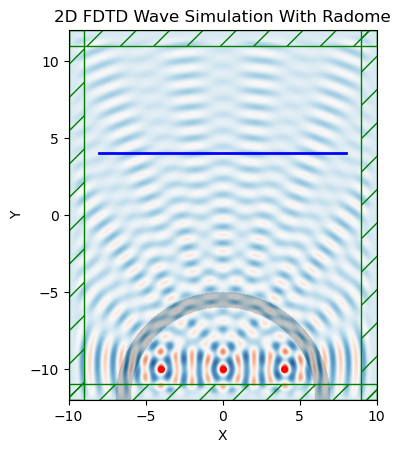

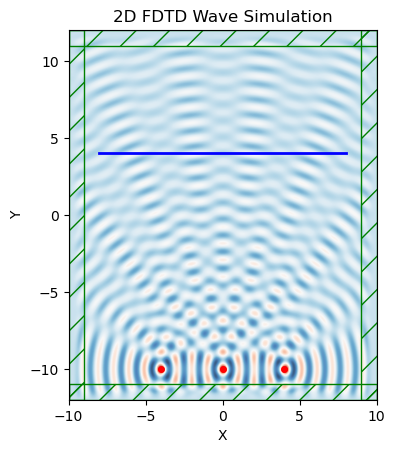

The field data with radome 189.05305056556168
The field data without radome 220.2588101942193
Insertion Loss {Accurate} :  0.6634959935531122
Insertion Loss {Rough} :  0.6987140265626369


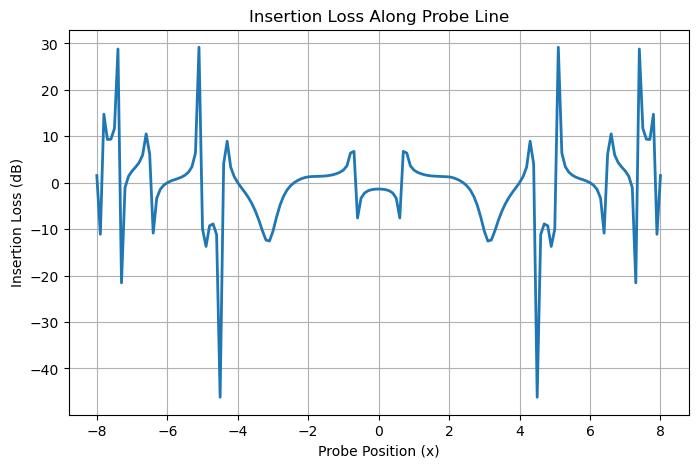

In [9]:
import meep as mp
import matplotlib.pyplot as plt
import numpy as np

cell = mp.Vector3(20,24,0) # cell is more like a workspace so geomentry defined are into this area has 3 Dimensions but I choose 2D

probe_dir = 4
n_probe = np.linspace(-8,8,161) 
Reading_1 = []
Reading_2 = []

# Parameters Based on TI Radome Design guide paper
freq = 1 # 16GHz based on MEEP unit (Refer notes for more detail) {Ku band}
src_pos = 0
radome_t = 1.5
radome_center = 2.0 
epsilon_r = 2 # refer the TI paper the reason for Er = 2 coz the material is Teflom?
radome_mat = mp.Medium(epsilon = epsilon_r) 

#  Geometry of the Radome based on COMSOL desgin 
radome_dome_rad = 7

geometry = [
    
    
    mp.Sphere(
        radius = radome_dome_rad,
        center = mp.Vector3(0, -12, 0),
        material = radome_mat
    ),
       
    mp.Sphere(
        radius = (radome_dome_rad-1),
        center = mp.Vector3(0, -12, 0),
        material = mp.air
    )



]

source_1 = mp.Source(mp.ContinuousSource(frequency=freq),
                     component = mp.Ez,
                     center = mp.Vector3(0, -10, 0))
source_2 = mp.Source(mp.ContinuousSource(frequency=freq),
                     component = mp.Ez,
                     center = mp.Vector3(-4, -10, 0))
source_3 = mp.Source(mp.ContinuousSource(frequency=freq),
                     component = mp.Ez,
                     center = mp.Vector3(4, -10, 0))

flux_region = mp.FluxRegion(center=mp.Vector3(0,4,0),size=mp.Vector3(16,0,0))

pml_layers = [mp.PML(1)]


sim_1 = mp.Simulation(cell_size=cell, boundary_layers=pml_layers, geometry=geometry, sources=(source_1,source_2,source_3), resolution=20)
trans_flux_1 = sim_1.add_flux(freq,0,1,flux_region)
sim_1.run(until=100)
P_with = mp.get_fluxes(trans_flux_1)[0]

sim_2 = mp.Simulation(cell_size=cell, boundary_layers=pml_layers, sources=(source_1,source_2,source_3), resolution=20)
trans_flux_2 = sim_2.add_flux(freq,0,1,flux_region)
sim_2.run(until=100)
P_without = mp.get_fluxes(trans_flux_2)[0]

for i in n_probe:
    Reading_1.append(abs(sim_1.get_field_point(mp.Ez, mp.Vector3(i, probe_dir))))
    Reading_2.append(abs(sim_2.get_field_point(mp.Ez, mp.Vector3(i, probe_dir))))

Reading_1 = np.array(Reading_1)
Reading_2 = np.array(Reading_2)

# Simulation with radome, 
plt.figure()
sim_1.plot2D(fields=mp.Ez)
plt.title("2D FDTD Wave Simulation With Radome")
plt.show()

# Simulation without radome, 
plt.figure()
sim_2.plot2D(fields=mp.Ez)
plt.title("2D FDTD Wave Simulation")
plt.show()

#Calculations for Analysis
Probe_in_sim1 = np.sum(Reading_1**2)
Probe_in_sim2 = np.sum(Reading_2**2)
IL = -10*np.log10(P_with/P_without) #Insertion Loss
IL_rough = -10*np.log10(Probe_in_sim1/Probe_in_sim2)

print("The field data with radome", P_with)
print("The field data without radome", P_without)
print("Insertion Loss {Accurate} : ",IL)
print("Insertion Loss {Rough} : ",IL_rough)

eps = 1e-12

IL_profile = -20*np.log10(
    (Reading_1 + eps) /
    (Reading_2 + eps)
)
